# Training the U-Net

Train a U-Net to segment my 4 land-cover classes (forest / agriculture / urban / water) from the 6-band Sentinel-2 tiles built in Notebook 4.

**Pieces:** a `Dataset` that reads the `.npz` tiles (remap bare→agriculture, normalise, augment) → a U-Net from `segmentation-models-pytorch` → a **class-weighted** loss → a training loop that reports **per-class IoU** (not just accuracy, which would be a lie at 87% forest) and checkpoints the best model to Drive.

## 0. Install + imports

In [1]:
!pip install -q segmentation-models-pytorch albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 12.4 MB/s eta 0:00:00


In [2]:
import os, glob, numpy as np, torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [3]:
!pip install -q rasterio
from google.colab import drive
import numpy as np, rasterio
drive.mount("/content/drive")

GEOTIFF = "/content/drive/MyDrive/landcover_riau/indragiri_2021_stack.tif"
CKPT    = "/content/drive/MyDrive/landcover_riau/unet_best.pt"
TILE, STRIDE, VALID_FRAC, VAL_FRACTION_X = 256, 256, 0.95, 0.2

with rasterio.open(GEOTIFF) as src:
    arr = np.nan_to_num(src.read(), nan=0.0)          # (8,H,W): 6 img + class + valid
img_b, msk_b, val_b = arr[:6].astype(np.float32), arr[6].astype(np.uint8), arr[7]
H, W = msk_b.shape
x_cut = (1 - VAL_FRACTION_X) * W

images, masks, splits = [], [], []
for y in range(0, H - TILE + 1, STRIDE):
    for x in range(0, W - TILE + 1, STRIDE):
        if val_b[y:y+TILE, x:x+TILE].mean() < VALID_FRAC:
            continue
        images.append(img_b[:, y:y+TILE, x:x+TILE])
        masks.append(msk_b[y:y+TILE, x:x+TILE])
        splits.append("val" if x >= x_cut else "train")

images, masks, splits = np.stack(images), np.stack(masks), np.array(splits)
train_idx = np.where(splits == "train")[0]
val_idx   = np.where(splits == "val")[0]
print("tiled in memory:", images.shape, "| train:", len(train_idx), "val:", len(val_idx))

Mounted at /content/drive
tiled in memory: (441, 6, 256, 256) | train: 378 val: 63


## 1. Config

4 classes; `bare` (the old class 4) gets folded into `agriculture`. Imagery is Sentinel-2 surface reflectance scaled ×10000, so dividing by 10000 puts it in physical reflectance ~[0, 1].

In [4]:
N_CLASSES = 4
CLASSES = {0: "forest", 1: "agriculture", 2: "urban", 3: "water"}
CLASS_COLORS = ["#1b7837", "#e6c200", "#d7191c", "#2c7fb8"]
N_BANDS = 6                 # B2,B3,B4,B8,B11,B12
REFL_SCALE = 10000.0
BATCH = 16
EPOCHS = 40
LR = 1e-3

## 2. Dataset + augmentation

Augmentation is **geometry only** (flips, 90° rotations). Colour jitter assumes RGB photos and would corrupt the physical meaning of the spectral bands. The same transform is applied to image and mask so they stay aligned.

In [5]:
train_tf = A.Compose([A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5), A.RandomRotate90(p=0.5), ToTensorV2()])
val_tf = A.Compose([ToTensorV2()])

class TileDataset(Dataset):
    def __init__(self, images, masks, idx, tf):
        self.images, self.masks, self.idx, self.tf = images, masks, idx, tf
    def __len__(self):
        return len(self.idx)
    def __getitem__(self, j):
        i = self.idx[j]
        img = np.nan_to_num(self.images[i].astype(np.float32) / REFL_SCALE)
        img = np.transpose(img, (1, 2, 0))
        mask = self.masks[i].astype(np.int64)
        mask[mask == 4] = 1
        mask = np.where((mask >= 0) & (mask < N_CLASSES), mask, 0)
        out = self.tf(image=img, mask=mask)
        return out["image"].float(), out["mask"].long()

train_ds = TileDataset(images, masks, train_idx, train_tf)
val_ds   = TileDataset(images, masks, val_idx, val_tf)
x, y = train_ds[0]
print("image", tuple(x.shape), "| mask", tuple(y.shape), "classes:", torch.unique(y).tolist())

image (6, 256, 256) | mask (256, 256) classes: [0, 1]


## 3. Class weights (recomputed from the tiles)

Median-frequency balancing

In [6]:
m = masks[train_idx].astype(np.int64); m[m == 4] = 1
total = m.size
freq = np.array([(m == c).sum() / total for c in range(N_CLASSES)])
w = np.clip(np.median(freq) / freq, 0.3, 6.0)
class_weights = torch.tensor(w, dtype=torch.float32, device=device)
print("mix:", {CLASSES[c]: f"{100*freq[c]:.1f}%" for c in range(N_CLASSES)})
print("weights:", {CLASSES[c]: round(float(w[c]), 3) for c in range(N_CLASSES)})

mix: {'forest': '87.1%', 'agriculture': '9.1%', 'urban': '0.6%', 'water': '3.3%'}
weights: {'forest': 0.3, 'agriculture': 0.681, 'urban': 6.0, 'water': 1.883}


In [7]:
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=0)

## 4. Model, loss, optimiser

`smp.Unet` with a ResNet-34 encoder. Ask for **ImageNet weights** even though I have 6 bands, not 3. `smp` adapts the first conv layer to the extra channels, which still gives a head start over random init. Loss is **weighted cross-entropy + Dice**: CE handles the per-pixel imbalance via the weights, Dice directly optimises region overlap (good for segmentation).

In [8]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=N_BANDS,
    classes=N_CLASSES,
).to(device)

ce_loss = nn.CrossEntropyLoss(weight=class_weights)
dice_loss = smp.losses.DiceLoss(mode="multiclass")

def criterion(logits, target):
    return ce_loss(logits, target) + dice_loss(logits, target)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:134: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

## 5. Metric: per-class IoU via a confusion matrix

I accumulate a 4×4 confusion matrix over the whole validation set, then IoU per class = `TP / (TP + FP + FN)`. Reporting **per-class** IoU (and their mean, mIoU) is the key here. Overall pixel accuracy would sit near 87% just by guessing forest.

In [9]:
def add_to_confusion(conf, pred, target, n=N_CLASSES):
    k = (target >= 0) & (target < n)
    conf += np.bincount(n * target[k] + pred[k], minlength=n * n).reshape(n, n)
    return conf

def per_class_iou(conf):
    tp = np.diag(conf).astype(np.float64)
    fp = conf.sum(0) - tp
    fn = conf.sum(1) - tp
    denom = tp + fp + fn
    return np.where(denom > 0, tp / denom, np.nan)

## 6. Train

Keeps the checkpoint with the best validation mIoU.

In [10]:
history = {"train_loss": [], "val_loss": [], "miou": []}
best_miou = 0.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    run = 0.0
    for img, mask in train_loader:
        img, mask = img.to(device), mask.to(device)
        optimizer.zero_grad()
        loss = criterion(model(img), mask)
        loss.backward(); optimizer.step()
        run += loss.item() * img.size(0)
    train_loss = run / len(train_ds)

    model.eval()
    conf = np.zeros((N_CLASSES, N_CLASSES), np.int64)
    run = 0.0
    with torch.no_grad():
        for img, mask in val_loader:
            img, mask = img.to(device), mask.to(device)
            logits = model(img)
            run += criterion(logits, mask).item() * img.size(0)
            pred = logits.argmax(1).cpu().numpy().ravel()
            conf = add_to_confusion(conf, pred, mask.cpu().numpy().ravel())
    val_loss = run / len(val_ds)
    ious = per_class_iou(conf); miou = np.nanmean(ious)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["miou"].append(miou)
    if miou > best_miou:
        best_miou = miou
        torch.save(model.state_dict(), CKPT)
        flag = "  <- saved best"
    else:
        flag = ""
    per_cls = "  ".join(f"{CLASSES[c][:3]}={ious[c]:.2f}" for c in range(N_CLASSES))
    print(f"ep {epoch:02d}  train {train_loss:.3f}  val {val_loss:.3f}  mIoU {miou:.3f}  [{per_cls}]{flag}")

print(f"\nbest val mIoU: {best_miou:.3f}  ->  {CKPT}")

ep 01  train 1.644  val 1.901  mIoU 0.327  [for=0.72  agr=0.26  urb=0.00  wat=0.32]  <- saved best
ep 02  train 0.997  val 2.052  mIoU 0.240  [for=0.77  agr=0.01  urb=0.16  wat=0.02]
ep 03  train 0.788  val 0.959  mIoU 0.575  [for=0.84  agr=0.17  urb=0.39  wat=0.91]  <- saved best
ep 04  train 0.698  val 1.480  mIoU 0.440  [for=0.83  agr=0.01  urb=0.12  wat=0.80]
ep 05  train 0.692  val 1.114  mIoU 0.588  [for=0.84  agr=0.01  urb=0.59  wat=0.92]  <- saved best
ep 06  train 0.720  val 0.858  mIoU 0.575  [for=0.85  agr=0.32  urb=0.29  wat=0.84]
ep 07  train 0.691  val 1.103  mIoU 0.444  [for=0.83  agr=0.35  urb=0.06  wat=0.54]
ep 08  train 0.629  val 0.647  mIoU 0.629  [for=0.82  agr=0.41  urb=0.39  wat=0.90]  <- saved best
ep 09  train 0.624  val 0.633  mIoU 0.704  [for=0.84  agr=0.39  urb=0.63  wat=0.95]  <- saved best
ep 10  train 0.587  val 0.601  mIoU 0.691  [for=0.82  agr=0.40  urb=0.62  wat=0.91]
ep 11  train 0.596  val 0.753  mIoU 0.593  [for=0.85  agr=0.17  urb=0.45  wat=0.90]
e

## 7. Training curves

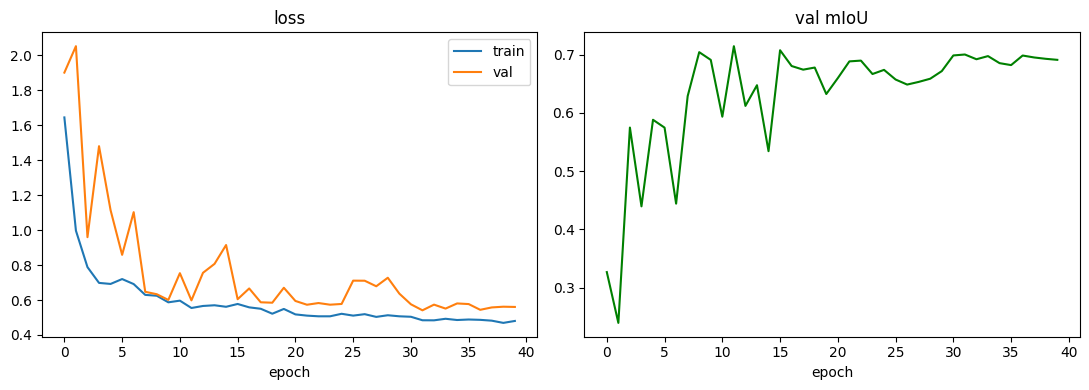

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(history["miou"], color="green"); ax[1].set_title("val mIoU"); ax[1].set_xlabel("epoch")
plt.tight_layout(); plt.show()

## 8. Qualitative check: Predictions vs truth

Load the best checkpoint and eyeball a few validation tiles: image | ground-truth label | prediction.

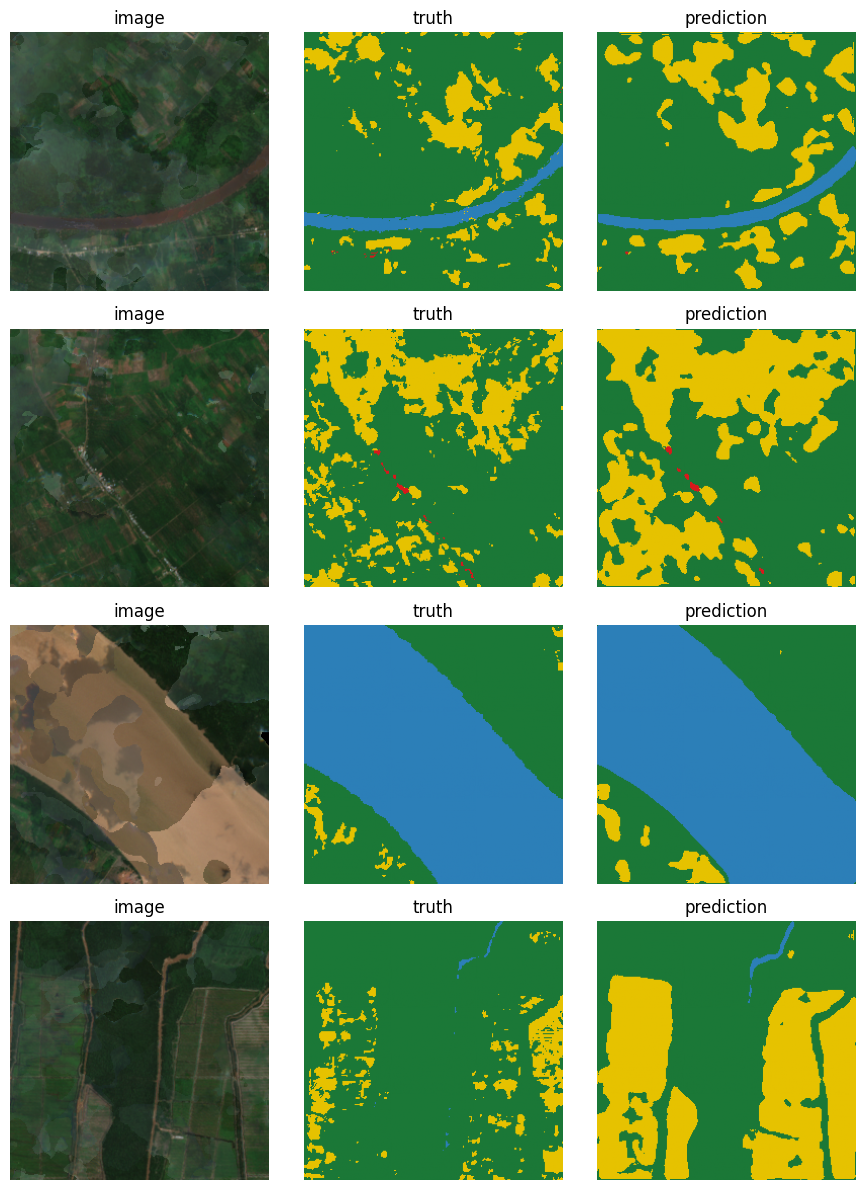

In [ ]:
model.load_state_dict(torch.load(CKPT)); model.eval()
cmap = ListedColormap(CLASS_COLORS)

n = 4
fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
with torch.no_grad():
    for row in range(n):
        img, mask = val_ds[row * (len(val_ds) // n)]
        pred = model(img.unsqueeze(0).to(device)).argmax(1)[0].cpu().numpy()
        rgb = img.numpy()[[2, 1, 0]].transpose(1, 2, 0) * (REFL_SCALE / 3000.0)
        axes[row, 0].imshow(np.clip(rgb, 0, 1)); axes[row, 0].set_title("image")
        axes[row, 1].imshow(mask.numpy(), cmap=cmap, vmin=0, vmax=N_CLASSES - 1); axes[row, 1].set_title("truth")
        axes[row, 2].imshow(pred, cmap=cmap, vmin=0, vmax=N_CLASSES - 1); axes[row, 2].set_title("prediction")
        for ax in axes[row]:
            ax.axis("off")
plt.tight_layout(); plt.show()